# Domain Adaptation: MMD Alignment (S2 to PhiSat-2)
This notebook trains the `terramind_v1_tiny` backbone to reduce the distribution discrepancy (MMD) between Sentinel-2 (Source) and PhiSat-2 (Target) embeddings. As we do not have labels for the target domain, this is an unsupervised domain adaptation task.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import h5py
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from terratorch import BACKBONE_REGISTRY
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


/shared/home/elucas/scratch/terra-sat-drift/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


# 1. Define MMD Loss
We use an RBF Kernel based Maximum Mean Discrepancy (MMD) loss to align the feature distributions.

In [2]:
class RBFKernel(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(RBFKernel, self).__init__()
        self.sigmas = torch.tensor(sigmas).to(device)

    def forward(self, X, Y):
        X_expanded = X.unsqueeze(1)
        Y_expanded = Y.unsqueeze(0)
        dist_squared = torch.sum((X_expanded - Y_expanded) ** 2, dim=2)
        kernel_val = torch.zeros_like(dist_squared)
        for sigma in self.sigmas:
            gamma = 1.0 / (2.0 * sigma ** 2)
            kernel_val += torch.exp(-gamma * dist_squared)
        return kernel_val / len(self.sigmas)

class MMDLoss(nn.Module):
    def __init__(self, sigmas=[1.0, 2.0, 4.0, 8.0, 16.0]):
        super(MMDLoss, self).__init__()
        self.kernel = RBFKernel(sigmas)

    def forward(self, X, Y):
        k_xx = self.kernel(X, X)
        k_yy = self.kernel(Y, Y)
        k_xy = self.kernel(X, Y)
        n, m = X.size(0), Y.size(0)
        mmd_squared = k_xx.sum() / (n * n) + k_yy.sum() / (m * m) - 2.0 * k_xy.sum() / (n * m)
        return torch.relu(mmd_squared)

# 2. Data Loading & Normalization
We load the triplets from the HDF5 file. For domain adaptation, we focus on the `s2b` (Source) and `real` (Target) pairs.

In [7]:
class PhiSatTripletDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(h5_path, 'r') as f:
            self.length = len(f['s2b/images'])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with h5py.File(self.h5_path, 'r') as f:
            s2_8b = f['sim/images'][idx][:7, :, :]
            # Load 7 bands: B02, B03, B04, B05, B06, B07, B08
            real_8b = f['real/images'][idx][:7, :, :]
            
        return torch.from_numpy(s2_8b).float(), torch.from_numpy(real_8b).float()

# Normalization for S2B
def normalize_for_encoder(img):
    img = img / 10000.0
    img = torch.clamp(img, 0, 1)
    return img

# Means and Stds for the 8 bands (B02, B03, B04, PAN, B08, B05, B06, B07)
# Estimates based on S2 stats
MEANS = [0.2137385, 0.2018788, 0.2082986, 0.2295651, 0.2854537, 0.3122849, 0.3040560]
STDS = [0.1675806, 0.1557708, 0.1833702, 0.1823738, 0.1733977, 0.1732131, 0.1679732]

def prepare_for_encoder(img):
    return TF.normalize(img, mean=MEANS, std=STDS)


# 3. Model Initialization
Initialize the `terramind_v1_tiny` backbone.

In [ ]:
backbone_name = "terramind_v1_base"

COMPARED_BANDS = {
    "S2L1C": {
        "B02": 0, "B03": 1, "B04": 2, 
        "B05": 3, "B06": 4, "B07": 5, "B08": 6,
    }
}

model = BACKBONE_REGISTRY.build(
    backbone_name,
    pretrained=True,
    modalities=["S2L1C"],
    bands=COMPARED_BANDS,
).to(device)

model.train()


TerraMindViT(
  (encoder_embeddings): ModuleDict(
    (untok_sen2l1c@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=1792, out_features=192, bias=False)
    )
  )
  (encoder): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm()
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm()
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=768, out_features=192, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm()
  (tokenizer): ModuleDict()
)

In [11]:
frozen_model = BACKBONE_REGISTRY.build(
    backbone_name,
    pretrained=True,
    modalities=["S2L1C"],
    bands=COMPARED_BANDS,
).to(device)

frozen_model.eval()
for param in frozen_model.parameters():
    param.requires_grad = False

# 4. Training Loop (Unsupervised Domain Adaptation)
We minimize the MMD loss between the S2 source embeddings and PhiSat-2 target embeddings.

Starting Domain Adaptation on 2000 samples...


Epoch 1/5:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/250 [00:00<?, ?it/s]

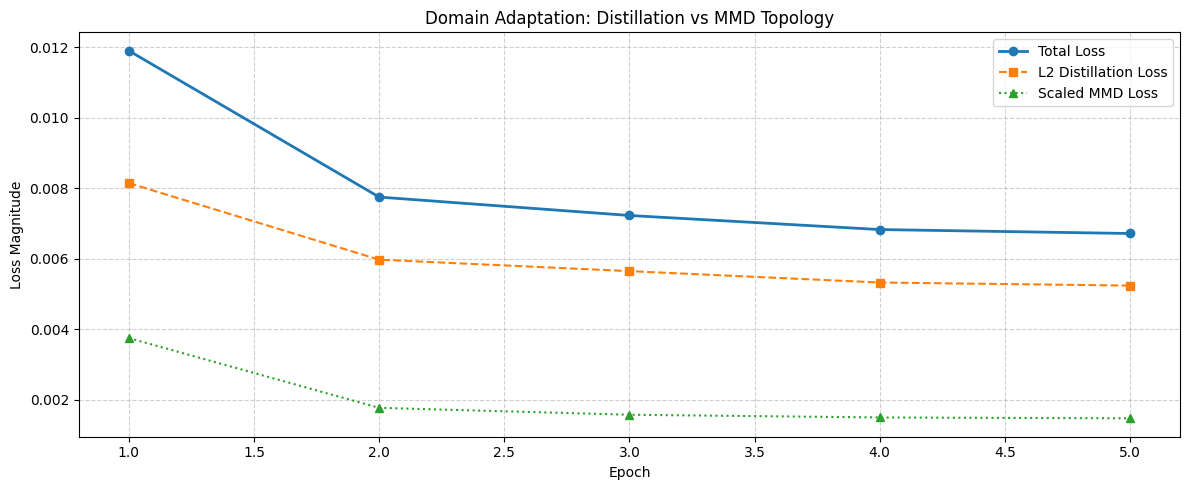

Training Complete. Weights saved to: /shared/home/elucas/scratch/terra-sat-drift/terramind_tiny_uda_mmd.pth


In [ ]:
h5_path = "/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5"
full_dataset = PhiSatTripletDataset(h5_path)

subset_size = 2000
torch.manual_seed(42) # For reproducibility
indices = torch.randperm(len(full_dataset))[:subset_size]
dataset = torch.utils.data.Subset(full_dataset, indices)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=4)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
LAMBDA_MMD = 0.5

mse_criterion = nn.MSELoss()
mmd_criterion = MMDLoss().to(device)

epochs = 5
history = {"total": [], "mmd": [], "distill": []}

print(f"Starting Domain Adaptation on {subset_size} samples...")

for epoch in range(epochs):
    epoch_loss = 0
    epoch_mmd = 0
    epoch_distill = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    for s2_batch, real_batch in pbar:
        optimizer.zero_grad()
        
        # Optimize normalization using the batched tensor function defined previously
        s2_input = normalize_for_encoder(s2_batch.to(device))
        real_input = normalize_for_encoder(real_batch.to(device))
        
        # --- A. L2 Distillation Anchor (Frozen Forward Pass) ---
        with torch.no_grad():
            frozen_s2_features = frozen_model(s2_input)[-1]
            frozen_real_features = frozen_model(real_input)[-1]
            
            # Extract frozen semantic representations
            frozen_s2_emb = frozen_s2_features.mean(dim=1)
            frozen_real_emb = frozen_real_features.mean(dim=1)

        # --- B. Domain Adaptation (Active Forward Pass) ---
        s2_features = model(s2_input)[-1]
        real_features = model(real_input)[-1]
        
        s2_emb = s2_features.mean(dim=1)
        real_emb = real_features.mean(dim=1)
        
        # --- C. Mean-Centering to Prevent Anisotropy ---
        # Subtract the batch mean before calculating MMD to destroy the dominant principal component
        s2_centered = s2_emb - s2_emb.mean(dim=0, keepdim=True)
        real_centered = real_emb - real_emb.mean(dim=0, keepdim=True)
        
        # --- D. Loss Calculation ---
        # 1. Distillation Loss (Mean Squared Error) ensures semantics are preserved
        loss_distill_s2 = mse_criterion(s2_emb, frozen_s2_emb)
        loss_distill_real = mse_criterion(real_emb, frozen_real_emb)
        loss_distill = loss_distill_s2 + loss_distill_real
        
        # 2. MMD Loss ensures domain distributions align
        loss_mmd = mmd_criterion(s2_centered, real_centered)
        
        # Combine losses
        loss = loss_distill + (LAMBDA_MMD * loss_mmd)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_mmd += loss_mmd.item()
        epoch_distill += loss_distill.item()
        
        pbar.set_postfix({
            "Total": f"{loss.item():.4f}", 
            "Distill": f"{loss_distill.item():.4f}", 
            "MMD": f"{loss_mmd.item():.4f}"
        })
    
    # Store metrics for visualization
    history["total"].append(epoch_loss / len(dataloader))
    history["mmd"].append(epoch_mmd / len(dataloader))
    history["distill"].append(epoch_distill / len(dataloader))

plt.figure(figsize=(12, 5))
plt.plot(range(1, epochs + 1), history["total"], label="Total Loss", marker='o', linewidth=2)
plt.plot(range(1, epochs + 1), history["distill"], label="L2 Distillation Loss", marker='s', linestyle='--')
plt.plot(range(1, epochs + 1), [m * LAMBDA_MMD for m in history["mmd"]], label="Scaled MMD Loss", marker='^', linestyle=':')
plt.title("Domain Adaptation: Distillation vs MMD Topology")
plt.xlabel("Epoch")
plt.ylabel("Loss Magnitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

save_weights_path = f"/shared/home/elucas/scratch/terra-sat-drift/outputs/terramind_{backbone_name}_uda_mmd.pth"
torch.save(model.state_dict(), save_weights_path)
print(f"Training Complete. Weights saved to: {save_weights_path}")